In [1]:
import sys
try:
    import blpapi
    print("blpapi version:", blpapi.__version__)
except ImportError:
    print("blpapi not installed.")

try:
    import xbbg
    print("xbbg installed.")
except ImportError:
    print("xbbg not installed.")

blpapi not installed.
xbbg not installed.


In [2]:
from xbbg import blp
import pandas as pd

try:
    # Use the async version abdh as suggested
    df = await blp.abdh('SPX Index', ['px_last'], '2023-01-01', '2023-12-31')
    print("Data fetched successfully:")
    print(df.head())
except Exception as e:
    print(f"Error connecting to Bloomberg API: {e}")
    print("Ensure that the Bloomberg Terminal or API service is running and accessible.")

Data fetched successfully:
┌───────────────────────────────────────────────────────────────────────┐
|                          Narwhals DataFrame                           |
|-----------------------------------------------------------------------|
|pyarrow.Table                                                          |
|ticker: string                                                         |
|date: date32[day]                                                      |
|field: string                                                          |
|value: double                                                          |
|----                                                                   |
|ticker: [["SPX Index","SPX Index","SPX Index","SPX Index","SPX Index"]]|
|date: [[2023-01-03,2023-01-04,2023-01-05,2023-01-06,2023-01-09]]       |
|field: [["px_last","px_last","px_last","px_last","px_last"]]           |
|value: [[3824.14,3852.97,3808.1,3895.08,3892.09]]                      |
└──────────

In [30]:
df.to_pandas()

,ticker,date,field,value
0,SPX Index,2023-01-03,px_last,3824.14
1,SPX Index,2023-01-04,px_last,3852.97
2,SPX Index,2023-01-05,px_last,3808.10
3,SPX Index,2023-01-06,px_last,3895.08
4,SPX Index,2023-01-09,px_last,3892.09
...,...,...,...,...
245,SPX Index,2023-12-22,px_last,4754.63
246,SPX Index,2023-12-26,px_last,4774.75
247,SPX Index,2023-12-27,px_last,4781.58
248,SPX Index,2023-12-28,px_last,4783.35


Matplotlib is building the font cache; this may take a moment.


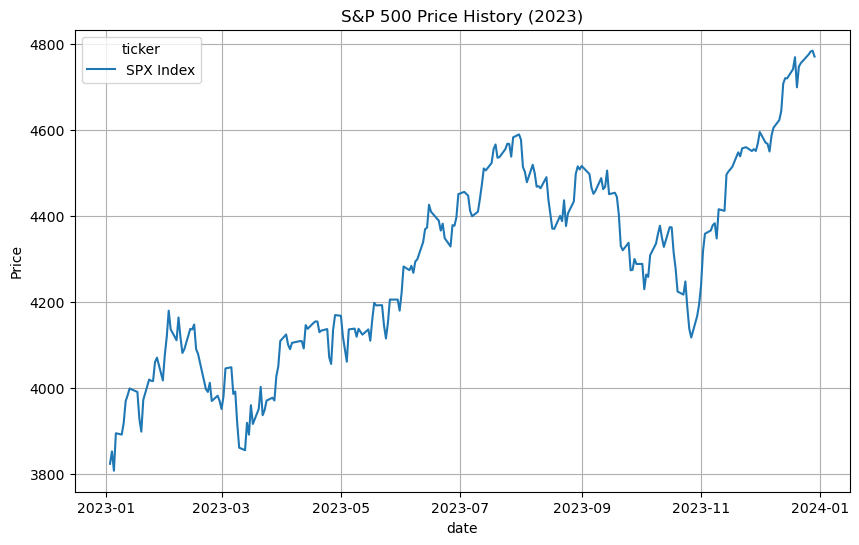

ticker,SPX Index
date,
2023-01-03,3824.14
2023-01-04,3852.97
2023-01-05,3808.10
2023-01-06,3895.08
2023-01-09,3892.09


In [27]:
# Convert to pandas and clean up the structure
if hasattr(df, 'to_pandas'):
    pd_df = df.to_pandas()
else:
    pd_df = df # Already a DataFrame or similar

# Pivot the data to have dates as index and columns as tickers/fields
pivot_df = pd_df.pivot(index='date', columns='ticker', values='value')

# Display and plot
import matplotlib.pyplot as plt
pivot_df.plot(title='S&P 500 Price History (2023)', figsize=(10, 6))
plt.ylabel('Price')
plt.grid(True)
plt.show()

pivot_df.head()